# Regional Site Setup

Scan **every** GHCN-Daily station inside the Pacific EEZ area of interest, check each one against a set of quality filters, and collect the stations that pass — together with their cleaned daily data — into a single dictionary.

This is the regional counterpart of [`00_site_setup.ipynb`](00_site_setup.ipynb): that notebook sets up **one** station picked interactively; this one sets up **many** stations at once for a region, so you can build multi-station / regional maps (e.g. with `functions/rainfall_regional.py`) without repeating the single-site workflow by hand.

**Outputs:**
- `data/regional/<region_key>_stations.pkl` — dictionary `{station_id: {..metadata.., "data": DataFrame}}` for every station that passed the filters.
- `data/regional/<region_key>_summary.json` — lightweight metadata-only summary (no dataframes) of accepted **and** rejected stations, with the reason each rejected station was dropped.
- `data/regional/<region_key>/GHCN_<station_id>.pkl` — per-station raw cache (pre-filter), so re-running the notebook doesn't re-download from NOAA.

**Workflow overview:**

1. Load the Pacific EEZ polygons (the area of interest) and a `region_key` to name the outputs.
2. Set the variables of interest and the quality filters (minimum record length, completeness threshold).
3. Download the GHCN station catalog and inventory, and keep only stations inside a Pacific EEZ polygon.
4. Pre-filter candidates by metadata alone (element availability, record length) before downloading any daily data.
5. Download and clean each candidate station; apply the same completeness filter as `00_site_setup.ipynb`; keep it only if enough data survives.
6. Inspect the accepted/rejected stations (table + map).
7. Save the combined dictionary and the summary JSON.


In [1]:
import concurrent.futures
from pathlib import Path
import pickle
import sys

import geopandas as gpd
import numpy as np
import pandas as pd
import plotly.express as px
from IPython.display import display

sys.path.append("../../../functions")
from air_temp import site_config_filename
from data_downloaders import GHCN, filter_by_time_completeness
from rainfall_regional import load_pacific_eez

## 1. Define the area of interest

Instead of a manual lon/lat bounding box, the area of interest is now the **Pacific EEZ boundaries** — the same shapefile used by `create_pacific_base_map` / `load_pacific_eez` in `functions/rainfall_regional.py`. A station only qualifies if its coordinates fall **inside** one of these EEZ polygons (with a small buffer, see below). This is more precise than a box or a country-code exclusion list: it naturally excludes mainland Australia, New Zealand, Asia and the Americas (they have no polygon in this shapefile), while still including Pacific-Island territories whose GHCN station IDs happen to share a mainland country's prefix (e.g. Hawaii and Wake Island use `US`-prefixed IDs, same as the continental US, but they get included because their *location* falls inside their own EEZ polygon).

`p_dat` points at the repository's `data/` folder — `load_pacific_eez` expects the shapefile at `<p_dat>/Pacific_EEZs/*.shp`.

**Why the polygons get a small buffer:** GHCN station coordinates and the digitized EEZ coastline don't always agree to the meter — a station sitting right at the water's edge (true of most small-island airports/harbors) can land just outside a strictly precise polygon boundary due to coordinate rounding or coastline simplification. A land station missing from its own country's EEZ is a data artifact, not a real exclusion, so each polygon is grown outward by `EEZ_BUFFER_DEG` degrees (≈ a few km) before the containment test — small enough that it can't bridge the hundreds of km separating Pacific EEZs from each other or from excluded mainlands.


In [ ]:
region_key = "pacific"  # used to name data/regional/<region_key>_*
p_dat = Path("../../../../data")  # load_pacific_eez looks for <p_dat>/Pacific_EEZs/*.shp
EEZ_BUFFER_DEG = 0.05  # ~5 km; absorbs coastline digitization / GPS precision mismatches

eez_gdf = load_pacific_eez(p_dat)
if eez_gdf.crs is None:
    eez_gdf = eez_gdf.set_crs("EPSG:4326")

# Some EEZ shapefiles cut the landmass out of the maritime polygon as an interior
# hole; rebuild each polygon from its exterior ring only so land counts as part of
# the EEZ, then grow every polygon outward by EEZ_BUFFER_DEG to absorb the
# coastline/precision mismatches described above (e.g. a coastal station like
# Koror, Palau (PSW00040309) landing just outside the digitized boundary).
from shapely.geometry import Polygon, MultiPolygon


def _fill_holes(geom):
    if isinstance(geom, Polygon):
        return Polygon(geom.exterior)
    if isinstance(geom, MultiPolygon):
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms])
    return geom


n_with_holes = int(
    eez_gdf["geometry"]
    .apply(lambda g: len(g.interiors) if isinstance(g, Polygon) else 0)
    .astype(bool)
    .sum()
)
eez_gdf["geometry"] = eez_gdf["geometry"].apply(_fill_holes).buffer(EEZ_BUFFER_DEG)

print(f"Loaded {len(eez_gdf)} Pacific EEZ polygons from {p_dat / 'Pacific_EEZs'}")
print(f"Filled interior holes (land cut-outs) in {n_with_holes} polygon(s); buffered all by {EEZ_BUFFER_DEG}°.")

/var/folders/88/z9xxhn052qddjc_ppp2j_8gr0000gn/T/ipykernel_82766/2571264788.py:31: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  eez_gdf["geometry"] = eez_gdf["geometry"].apply(_fill_holes).buffer(EEZ_BUFFER_DEG)


Loaded 29 Pacific EEZ polygons from ../../../data/Pacific_EEZs
Filled interior holes (land cut-outs) in 25 polygon(s); buffered all by 0.05°.


## 2. Variables of interest and quality filters

| Parameter | Default | Description |
|---|---|---|
| `vars_of_interest` | `["TMIN", "TMAX", "PRCP"]` | A station is a candidate if its inventory reports **at least one** of these. |
| `min_years_before_download` | `20` | Metadata-only filter (cheap): minimum span of years on record for any variable of interest, before downloading any daily data. |
| `completeness_threshold` | `0.75` | Same month/year completeness filter as `00_site_setup.ipynb` (`filter_by_time_completeness`). |
| `min_years_after_filter` | `20` | A station is rejected if fewer than this many years survive the completeness filter. |
| `max_stations` | `None` | Optional cap on how many candidate stations to download, for a quick test run over a large area. Set to an integer to limit it. |
| `max_workers` | `8` | Number of stations downloaded **in parallel** in Section 5 (thread pool — this is I/O-bound, waiting on NOAA, not CPU-bound). Raise it for more speed, but be considerate of NOAA's servers; lower it if you see connection errors. |
| `force_redownload` | `False` | Set `True` to bypass the per-station cache and re-download from NOAA. |


In [ ]:
vars_of_interest = ["TMIN", "TMAX", "PRCP"]
min_years_before_download = 10
completeness_threshold = 0.75
min_years_after_filter = 20
max_stations = None
max_workers = 8
force_redownload = True

region_dir = Path("../../../data/regional")
region_cache_dir = region_dir / region_key
region_cache_dir.mkdir(parents=True, exist_ok=True)

print(f"Variables of interest: {vars_of_interest}")
print(f"Minimum years before download: {min_years_before_download}")
print(f"Completeness threshold: {completeness_threshold:.0%}")
print(f"Minimum years after completeness filter: {min_years_after_filter}")
print(f"Parallel downloads: {max_workers}")

## 3. Download the GHCN catalog and keep stations inside the Pacific EEZ

Downloads the full GHCN-Daily station list and element inventory (same source as `00_site_setup.ipynb`), then keeps only stations whose coordinates fall inside one of the Pacific EEZ polygons loaded in Step 1 (holes filled, buffered by `EEZ_BUFFER_DEG`) — a spatial join (`geopandas.sjoin(..., predicate="intersects")`) against every GHCN station worldwide (fast: a few hundred thousand point-in-polygon tests take well under a minute). Each accepted station is tagged with which EEZ (`eez_country`) it belongs to.


In [4]:
df_stations = GHCN.download_stations_info()
df_inventory = GHCN.download_station_inventory()

stations_gdf = gpd.GeoDataFrame(
    df_stations,
    geometry=gpd.points_from_xy(df_stations["Longitude"], df_stations["Latitude"]),
    crs="EPSG:4326",
).to_crs(eez_gdf.crs)

joined = gpd.sjoin(stations_gdf, eez_gdf[["Country", "geometry"]], how="inner", predicate="intersects")
joined = joined.drop_duplicates(subset="ID")

df_area_stations = (
    pd.DataFrame(joined.drop(columns=["geometry", "index_right"]))
    .rename(columns={"Country": "eez_country"})
    .reset_index(drop=True)
)

print(f"{len(df_area_stations)} / {len(df_stations)} GHCN stations fall inside a Pacific EEZ polygon "
      f"(out of {len(eez_gdf)} EEZ zones).")

1030 / 132501 GHCN stations fall inside a Pacific EEZ polygon (out of 29 EEZ zones).


### Map: stations inside vs. outside the Pacific EEZ

Static sanity-check map (reusing `create_pacific_base_map` from `functions/rainfall_regional.py`, the same EEZ + land base map used elsewhere in this repo) — green points passed the EEZ containment test, red points are GHCN stations nearby that didn't.


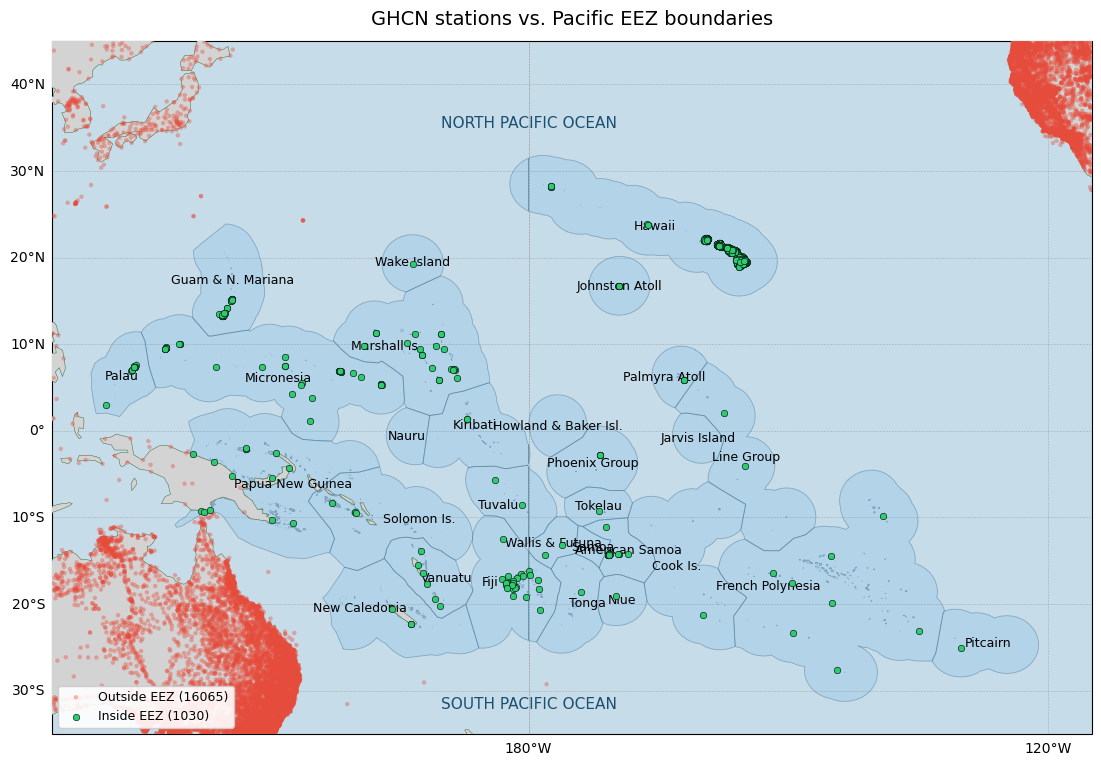

In [5]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from rainfall_regional import create_pacific_base_map, PACIFIC_EXTENT


def _normalize_lon_for_view(lon, lon_min):
    lon = np.asarray(lon, dtype=float)
    return np.where(lon < lon_min, lon + 360, lon)


# Restrict "outside" stations to the map's own viewing extent, otherwise we'd be
# plotting (and transforming) a large fraction of the world's ~130k GHCN stations
# for points that would never be visible anyway.
view_lon_min, view_lon_max, view_lat_min, view_lat_max = PACIFIC_EXTENT
lon_mapped_view = _normalize_lon_for_view(df_stations["Longitude"].values, view_lon_min)
in_view = (
    (lon_mapped_view >= view_lon_min) & (lon_mapped_view <= view_lon_max)
    & (df_stations["Latitude"] >= view_lat_min) & (df_stations["Latitude"] <= view_lat_max)
)
inside_ids = set(df_area_stations["ID"])
outside_in_view = df_stations.loc[in_view & ~df_stations["ID"].isin(inside_ids)]

fig, ax, _ = create_pacific_base_map(p_dat, figsize=(14, 9))

ax.scatter(
    outside_in_view["Longitude"], outside_in_view["Latitude"],
    transform=ccrs.PlateCarree(),
    s=10, c="#e74c3c", alpha=0.4, edgecolors="none",
    zorder=5, label=f"Outside EEZ ({len(outside_in_view)})",
)
ax.scatter(
    df_area_stations["Longitude"], df_area_stations["Latitude"],
    transform=ccrs.PlateCarree(),
    s=22, c="#2ecc71", edgecolors="black", linewidths=0.4,
    zorder=6, label=f"Inside EEZ ({len(df_area_stations)})",
)
ax.legend(loc="lower left", framealpha=0.9, fontsize=9)
ax.set_title("GHCN stations vs. Pacific EEZ boundaries", fontsize=14, pad=12)
plt.show()

## 4. Metadata pre-filter

Before downloading any daily data, drop stations that clearly won't pass:
- must report **at least one** variable in `vars_of_interest`;
- must have **at least `min_years_before_download` years** of combined record for those variables.

This is the same `GHCN.summarize_record_years` helper used in `00_site_setup.ipynb`, just applied to every station in the box instead of one.


In [6]:
record_years = GHCN.summarize_record_years(
    df_inventory, df_area_stations["ID"], elements=tuple(vars_of_interest)
)
df_area_stations = df_area_stations.merge(record_years, on="ID", how="left")

has_elements = df_area_stations["elements"].notna() & (df_area_stations["elements"] != "")
long_enough = (df_area_stations["record_end"] - df_area_stations["record_start"] + 1) >= min_years_before_download

candidates = df_area_stations.loc[has_elements & long_enough].reset_index(drop=True)
dropped_metadata = df_area_stations.loc[~(has_elements & long_enough)]

print(f"{len(candidates)} / {len(df_area_stations)} stations pass the metadata pre-filter.")
print(f"  - {int((~has_elements).sum())} report none of {vars_of_interest}.")
print(f"  - {int((has_elements & ~long_enough).sum())} report < {min_years_before_download} years of record.")

if max_stations is not None and len(candidates) > max_stations:
    print(f"Capping to the first {max_stations} candidates (out of {len(candidates)}) via `max_stations`.")
    candidates = candidates.head(max_stations).reset_index(drop=True)

station_table_cols = ["ID", "Name", "eez_country", "Latitude", "Longitude", "Elevation", "record_start", "record_end", "record_years", "elements"]
display(candidates[station_table_cols])

690 / 1030 stations pass the metadata pre-filter.
  - 14 report none of ['TMIN', 'TMAX', 'PRCP'].
  - 326 report < 10 years of record.


,ID,Name,eez_country,Latitude,Longitude,Elevation,record_start,record_end,record_years,elements
0,AQC00914000,AS AASUFOU,American Samoa,-14.3167,-170.7667,408.4,1980.0,2024.0,1980-2024,PRCP
1,AQC00914005,AS AFONO,American Samoa,-14.2667,-170.6500,182.9,1980.0,1998.0,1980-1998,PRCP
2,AQC00914135,AS FAGA ALU RSVR,American Samoa,-14.3000,-170.7000,249.9,1963.0,1976.0,1963-1976,PRCP
3,AQC00914248,AS FALEASAO VILLAGE,American Samoa,-14.2333,-169.5167,4.9,1975.0,1986.0,1975-1986,PRCP
4,AQC00914397,AS LEONE,American Samoa,-14.3500,-170.7833,6.1,1967.0,1978.0,1967-1978,"PRCP, TMAX, TMIN"
...,...,...,...,...,...,...,...,...,...,...
685,USW00022536,HI LIHUE WSO AP 1020.1 GSN 91165,Hawaii,21.9806,-159.3386,32.0,1950.0,2026.0,1950-2026,"PRCP, TMAX, TMIN"
686,USW00022551,HI EWA KALAELOA AP 91178,Hawaii,21.3056,-158.0658,3.0,1999.0,2026.0,1999-2026,"PRCP, TMAX, TMIN"
687,WF000917530,HIHIFO (ILE WALLIS) GSN 91753,Wallis and Futuna,-13.2330,-176.1670,27.0,1971.0,2025.0,1971-2025,"PRCP, TMAX, TMIN"
688,WFM00091754,FUTUNA ISL/MAOPOOPO 91754,Wallis and Futuna,-14.3170,-178.1170,36.0,1977.0,2025.0,1977-2025,"PRCP, TMAX, TMIN"


### Map: candidates vs. dropped by the metadata pre-filter

Same static base map as Section 3 — green points are `candidates` (kept), red points are `dropped_metadata` (no variable of interest, or too few years of record).


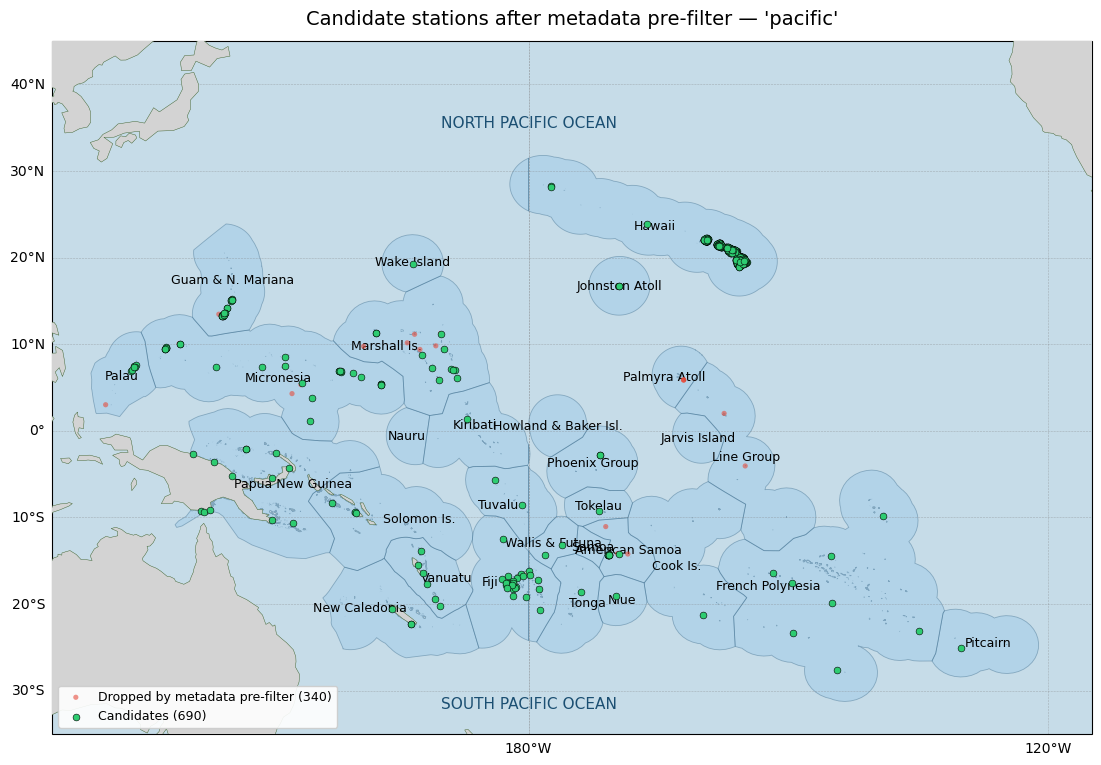

In [7]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from rainfall_regional import create_pacific_base_map

fig, ax, _ = create_pacific_base_map(p_dat, figsize=(14, 9))

ax.scatter(
    dropped_metadata["Longitude"], dropped_metadata["Latitude"],
    transform=ccrs.PlateCarree(),
    s=14, c="#e74c3c", alpha=0.6, edgecolors="none",
    zorder=5, label=f"Dropped by metadata pre-filter ({len(dropped_metadata)})",
)
ax.scatter(
    candidates["Longitude"], candidates["Latitude"],
    transform=ccrs.PlateCarree(),
    s=24, c="#2ecc71", edgecolors="black", linewidths=0.4,
    zorder=6, label=f"Candidates ({len(candidates)})",
)
ax.legend(loc="lower left", framealpha=0.9, fontsize=9)
ax.set_title(f"Candidate stations after metadata pre-filter — {region_key!r}", fontsize=14, pad=12)
plt.show()

## 5. Download, clean and filter every candidate station

Downloads run **in parallel** (`max_workers` threads at a time) since each one is just waiting on a NOAA HTTP response — this is I/O-bound, so a thread pool gives a large speed-up without needing multiple processes.

For each candidate: download the variables it reports (skipping any that turn out unavailable), derive `TMEAN`/`diff` when both `TMIN` and `TMAX` are present, apply the same `filter_by_time_completeness` used in `00_site_setup.ipynb`, and keep the station only if at least `min_years_after_filter` years survive. A station whose download/processing raises an error is treated as rejected (with the error as the reason) rather than stopping the whole batch.

Each station's raw (pre-filter) download is cached at `data/regional/<region_key>/GHCN_<station_id>.pkl` so re-running this cell after tweaking the filters doesn't re-hit NOAA. Set `force_redownload = True` above to refresh. Progress lines print in whatever order stations finish, not necessarily the candidate table's order.


In [8]:
GHCND_dir = "https://www.ncei.noaa.gov/data/global-historical-climatology-network-daily/access/"


def process_station(i):
    station = candidates.loc[i]
    station_id = station["ID"]
    try:
        cache_path = region_cache_dir / f"GHCN_{station_id}.pkl"

        if cache_path.exists() and not force_redownload:
            raw_data = pd.read_pickle(cache_path)
        else:
            df_target = candidates.loc[[i]]
            frames = []
            for var in vars_of_interest:
                result, _ = GHCN.extract_dict_data_var(GHCND_dir, var, df_target)
                if result:
                    frames.append(result[0]["data"])
            if not frames:
                return station_id, station["Name"], "rejected", "no data returned for any variable", None
            raw_data = pd.concat(frames, axis=1).dropna(how="all")
            raw_data.to_pickle(cache_path)

        if {"TMIN", "TMAX"}.issubset(raw_data.columns):
            raw_data = raw_data.dropna(subset=["TMIN", "TMAX"]).copy()
            raw_data["diff"] = raw_data["TMAX"] - raw_data["TMIN"]
            raw_data["TMEAN"] = (raw_data["TMAX"] + raw_data["TMIN"]) / 2

        filtered_data, _, _ = filter_by_time_completeness(
            raw_data, month_threshold=completeness_threshold, year_threshold=completeness_threshold,
        )
        n_years = len(np.unique(filtered_data.index.year)) if len(filtered_data) else 0

        if n_years < min_years_after_filter:
            reason = f"only {n_years} years survive completeness filter (< {min_years_after_filter})"
            return station_id, station["Name"], "rejected", reason, None

        record = {
            "station_id": station_id,
            "name": station["Name"],
            "country_code": str(station_id)[:2],
            "eez_country": station.get("eez_country"),
            "lat": float(station["Latitude"]),
            "lon": float(station["Longitude"]),
            "elevation": float(station["Elevation"]),
            "vars_available": [c for c in ("TMIN", "TMAX", "PRCP") if c in filtered_data.columns],
            "n_years": n_years,
            "period_start": int(filtered_data.index.year.min()),
            "period_end": int(filtered_data.index.year.max()),
            "data": filtered_data,
        }
        return station_id, station["Name"], "accepted", None, record
    except Exception as exc:
        return station_id, station["Name"], "rejected", f"error: {exc}", None


stations_data = {}
rejected_stations = {}
n_done = 0

with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
    futures = {executor.submit(process_station, i): i for i in candidates.index}
    for future in concurrent.futures.as_completed(futures):
        n_done += 1
        station_id, name, status, reason, record = future.result()
        if status == "accepted":
            stations_data[station_id] = record
            print(f"[{n_done}/{len(candidates)}] {station_id} - {name}: accepted ({record['n_years']} valid years)")
        else:
            rejected_stations[station_id] = {"name": name, "reason": reason}
            print(f"[{n_done}/{len(candidates)}] {station_id} - {name}: REJECTED ({reason})")

print()
print(f"Accepted {len(stations_data)} / {len(candidates)} candidate stations.")
print(f"Rejected {len(rejected_stations)}.")

[1/690] AQC00914594 - AS MALAELOA: REJECTED (only 9 years survive completeness filter (< 20))
[2/690] AQC00914873 - AS TAPUTIMU TUTUILA: REJECTED (only 10 years survive completeness filter (< 20))
[3/690] AQC00914248 - AS FALEASAO VILLAGE: REJECTED (only 12 years survive completeness filter (< 20))
[4/690] AQC00914005 - AS AFONO: REJECTED (only 15 years survive completeness filter (< 20))
[5/690] AQC00914135 - AS FAGA ALU RSVR: REJECTED (only 13 years survive completeness filter (< 20))
[6/690] AQC00914397 - AS LEONE: REJECTED (only 12 years survive completeness filter (< 20))
[7/690] AQC00914902 - AS VAIPITO: REJECTED (only 11 years survive completeness filter (< 20))
[8/690] AQC00914869 - AS TAFUNA AP TUTUILA: REJECTED (only 10 years survive completeness filter (< 20))
[9/690] AQC00914000 - AS AASUFOU: accepted (34 valid years)
[10/690] ASN00027002 - BOIGU: accepted (26 valid years)


/Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_Atmosphere/notebooks/historical/../../functions/data_downloaders.py:216: DtypeWarning: Columns (17,19,21,23,25,27,31,33,39,41,43,45,51,53,55,57,59,63,65,67,69,71,73,75,77,79,81,83,85,91,93,95,97,101) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url_download, na_values=["-9999"])


[11/690] CQC00914800 - MP ROTA: REJECTED (only 1 years survive completeness filter (< 20))
[12/690] BP000091503 - MUNDA GSN 91503: REJECTED (only 0 years survive completeness filter (< 20))
[13/690] ASN00027009 - DAUAN ISLAND: accepted (43 valid years)
[14/690] BPW00080601 - GUADALCANAL AAF GSN 91520: REJECTED (only 1 years survive completeness filter (< 20))
[15/690] CQC00914801 - MP ROTA AP 91221: accepted (27 valid years)
[16/690] CQW00041408 - MP SAIPAN MARSHALL ISLANDS 91232: REJECTED (only 3 years survive completeness filter (< 20))
[17/690] CQC00914874 - MP TINIAN 91231: accepted (28 valid years)
[18/690] CQC00914855 - MP SAIPAN INTL AP 91232: REJECTED (only 0 years survive completeness filter (< 20))
[19/690] CQC00914080 - MP CAPITOL HILL 1: accepted (29 valid years)
[20/690] BP000091517 - HONIARA 91517: REJECTED (only 0 years survive completeness filter (< 20))
[21/690] CQC00914860 - MP SAIPAN LORAN: accepted (21 valid years)
[22/690] CWM00091843 - RAROTONGA INTL GSN 91843: RE

/Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_Atmosphere/notebooks/historical/../../functions/data_downloaders.py:216: DtypeWarning: Columns (17,19,21,23,25,27,31,33,39,41,43,45,51,53,55,57,59,63,65,67,69,71,73,75,77,79,81,83,85,91,93,95,97,101) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url_download, na_values=["-9999"])


[26/690] FJM00091665 - Matei Airfield 91665: accepted (41 valid years)
[27/690] CQW00041418 - MP SAIPAN INTERNATIONAL AIRPORT: accepted (21 valid years)
[28/690] FJM00091670 - Viwa 91670: REJECTED (only 0 years survive completeness filter (< 20))
[29/690] FJM00091652 - Udu Point GSN 91652: REJECTED (only 2 years survive completeness filter (< 20))
[30/690] FJM00091672 - Nadarivatu 91672: accepted (27 valid years)
[31/690] FJM00091663 - Savusavu Airfield 91663: accepted (42 valid years)
[32/690] FJM00091660 - Yasawa-I-Rara 91660: accepted (40 valid years)
[33/690] FJM00091673 - Rarawai 91673: accepted (43 valid years)
[34/690] FJM00091676 - Vanuabalavu 91676: REJECTED (only 1 years survive completeness filter (< 20))
[35/690] FJM00091686 - Navua 91686: accepted (42 valid years)
[36/690] FJM00091691 - Lakeba 91691: accepted (43 valid years)
[37/690] FJM00091690 - Laucala Bay 91690: accepted (43 valid years)
[38/690] FJM00091697 - Matuku 91697: REJECTED (only 1 years survive completeness 

...

/Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_Atmosphere/notebooks/historical/../../functions/data_downloaders.py:216: DtypeWarning: Columns (17,19,21,23,25,27,29,31,35,37,39,41,43,45,47,49,51,53,55,57,59,61,63,65,67,69,71,73,77,79,83,85,87,89,91,95,97,99) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url_download, na_values=["-9999"])
/Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_Atmosphere/notebooks/historical/../../functions/data_downloaders.py:216: DtypeWarning: Columns (11,17,19,21,23,25,27,29,31,33,35,37,39,41,43,45,47,49,51,53,55,57,59,61,63,65,67,69,71,75,79,81,83,87,89,91,95,97,99) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url_download, na_values=["-9999"])


[688/690] USW00022516 - HI KAHULUI AP 91190: accepted (72 valid years)


/Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_Atmosphere/notebooks/historical/../../functions/data_downloaders.py:216: DtypeWarning: Columns (9,11,17,19,21,23,25,27,29,31,33,35,37,39,41,43,45,49,51,53,55,57,59,61,63,65,67,69,71,73,75,77,79,81,83,85,89,93,95,99,101,103,105,107,109,111,113,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url_download, na_values=["-9999"])


[689/690] USW00022536 - HI LIHUE WSO AP 1020.1 GSN 91165: accepted (77 valid years)
[690/690] USW00022521 - HI HONOLULU INTL AP 91182: accepted (82 valid years)

Accepted 294 / 690 candidate stations.
Rejected 396.


/Users/laurac/Library/Mobile Documents/com~apple~CloudDocs/Projects/CC_indicators/PICCM/PICCM_Atmosphere/notebooks/historical/../../functions/data_downloaders.py:216: DtypeWarning: Columns (17,19,21,23,25,27,29,31,35,37,39,41,43,45,47,49,51,53,55,57,59,61,63,65,67,69,71,73,77,79,83,85,87,89,91,95,97,99) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url_download, na_values=["-9999"])


## 6. Inspect the results


In [12]:
summary_rows = [
    {
        "station_id": s["station_id"],
        "name": s["name"],
        "eez_country": s.get("eez_country"),
        "lat": s["lat"],
        "lon": s["lon"],
        "vars_available": ", ".join(s["vars_available"]),
        "n_years": s["n_years"],
        "period": f"{s['period_start']}-{s['period_end']}",
    }
    for s in stations_data.values()
]
accepted_table = pd.DataFrame(summary_rows)
print(f"Accepted stations ({len(accepted_table)}):")
display(accepted_table)

if rejected_stations:
    rejected_table = pd.DataFrame(
        [{"station_id": sid, **info} for sid, info in rejected_stations.items()]
    )
    print(f"Rejected stations ({len(rejected_table)}):")
    display(rejected_table)

Accepted stations (294):


,station_id,name,eez_country,lat,lon,vars_available,n_years,period
0,AQC00914000,AS AASUFOU,American Samoa,-14.3167,-170.7667,PRCP,34,1980-2024
1,ASN00027002,BOIGU,Papua New Guinea,-9.2333,142.2167,PRCP,26,1927-1953
2,ASN00027009,DAUAN ISLAND,Papua New Guinea,-9.4000,142.5500,PRCP,43,1926-1972
3,CQC00914801,MP ROTA AP 91221,Northern Mariana Islands and Guam,14.1717,145.2428,"TMIN, TMAX, PRCP",27,1993-2026
4,CQC00914874,MP TINIAN 91231,Northern Mariana Islands and Guam,15.0000,145.6333,PRCP,28,1988-2024
...,...,...,...,...,...,...,...,...
289,USW00021504,HI HILO INTL AP 87 GSN 91285,Hawaii,19.7192,-155.0489,"TMIN, TMAX, PRCP",78,1949-2026
290,USW00022534,HI MOLOKAI KAUNAKAKAI MOLOKAI AP 91186,Hawaii,21.1544,-157.0961,"TMIN, TMAX, PRCP",77,1950-2026
291,USW00022516,HI KAHULUI AP 91190,Hawaii,20.8886,-156.4344,"TMIN, TMAX, PRCP",72,1954-2026
292,USW00022536,HI LIHUE WSO AP 1020.1 GSN 91165,Hawaii,21.9806,-159.3386,"TMIN, TMAX, PRCP",77,1950-2026


Rejected stations (396):


,station_id,name,reason
0,AQC00914594,AS MALAELOA,only 9 years survive completeness filter (< 20)
1,AQC00914873,AS TAPUTIMU TUTUILA,only 10 years survive completeness filter (< 20)
2,AQC00914248,AS FALEASAO VILLAGE,only 12 years survive completeness filter (< 20)
3,AQC00914005,AS AFONO,only 15 years survive completeness filter (< 20)
4,AQC00914135,AS FAGA ALU RSVR,only 13 years survive completeness filter (< 20)
...,...,...,...
391,USR0000HSFB,HI SCHOFIELD FIREBREAK HAWAII,only 9 years survive completeness filter (< 20)
392,USW00021508,HI BRADSHAW AAF,only 4 years survive completeness filter (< 20)
393,USW00022508,HI WHEELER AAF 810.1,only 14 years survive completeness filter (< 20)
394,USW00022525,HI PUUNENE,only 10 years survive completeness filter (< 20)


### Map of resulting stations

Same static base map as Sections 3–4 — green points are the final `accepted_table` (downloaded, completeness-filtered, kept); red points are candidates that were downloaded but rejected in Section 5 (no data, or too few years after the completeness filter).


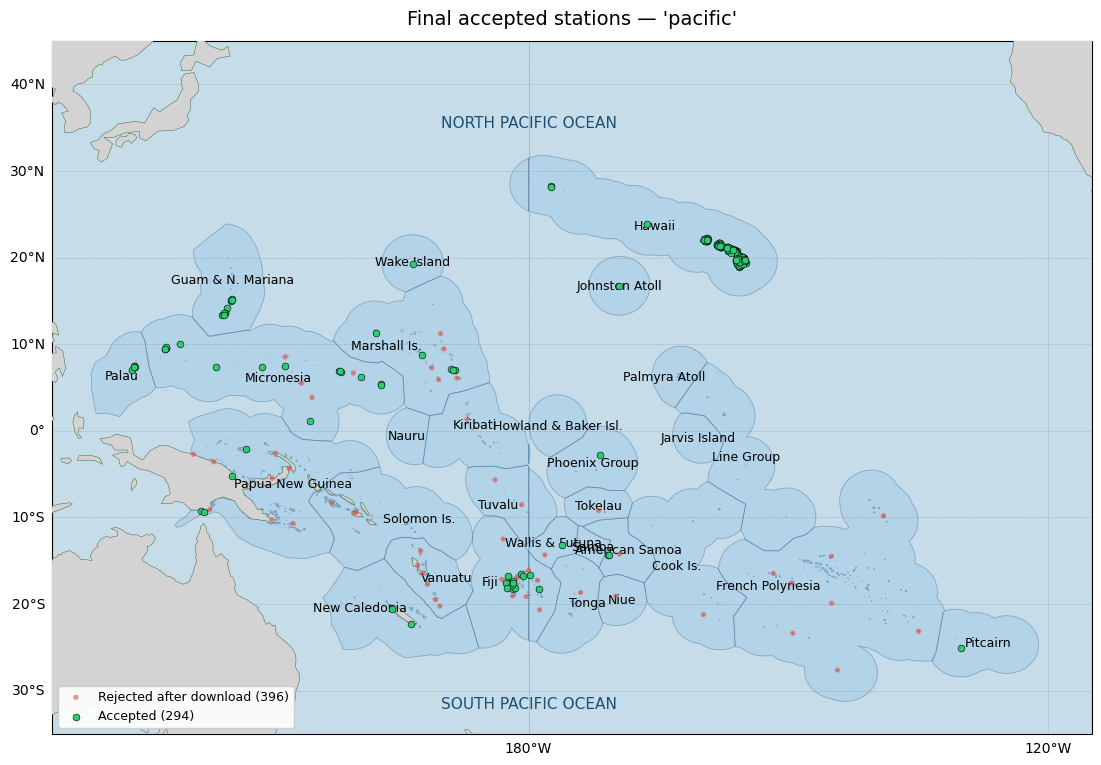

In [13]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from rainfall_regional import create_pacific_base_map

if len(accepted_table) or rejected_stations:
    fig, ax, _ = create_pacific_base_map(p_dat, figsize=(14, 9))

    if rejected_stations:
        rejected_geo = candidates.set_index("ID").loc[list(rejected_stations.keys()), ["Latitude", "Longitude"]]
        ax.scatter(
            rejected_geo["Longitude"], rejected_geo["Latitude"],
            transform=ccrs.PlateCarree(),
            s=14, c="#e74c3c", alpha=0.6, edgecolors="none",
            zorder=5, label=f"Rejected after download ({len(rejected_geo)})",
        )

    if len(accepted_table):
        ax.scatter(
            accepted_table["lon"], accepted_table["lat"],
            transform=ccrs.PlateCarree(),
            s=24, c="#2ecc71", edgecolors="black", linewidths=0.4,
            zorder=6, label=f"Accepted ({len(accepted_table)})",
        )

    ax.legend(loc="lower left", framealpha=0.9, fontsize=9)
    ax.set_title(f"Final accepted stations — {region_key!r}", fontsize=14, pad=12)
    plt.show()
else:
    print("No stations were accepted or rejected - nothing to plot.")

## 7. Save the regional dictionary and summary

- `data/regional/<region_key>_stations.pkl` — full dictionary, including each station's cleaned daily DataFrame. Load with `pickle.load(open(path, "rb"))`.
- `data/regional/<region_key>_summary.json` — metadata only (no dataframes), for a quick look without unpickling the full dataset.


In [14]:
region_slug = site_config_filename(region_key).replace(".json", "")

stations_pickle_path = region_dir / f"{region_slug}_stations.pkl"
with open(stations_pickle_path, "wb") as f:
    pickle.dump(stations_data, f)
print(f"Saved {len(stations_data)} stations to {stations_pickle_path}")

summary = {
    "region_key": region_key,
    "area_of_interest": "Pacific EEZ polygons",
    "eez_shapefile": str((p_dat / "Pacific_EEZs").resolve()),
    "eez_polygon_count": int(len(eez_gdf)),
    "vars_of_interest": vars_of_interest,
    "completeness_threshold": completeness_threshold,
    "min_years_after_filter": min_years_after_filter,
    "accepted": {
        sid: {k: v for k, v in s.items() if k != "data"}
        for sid, s in stations_data.items()
    },
    "rejected": rejected_stations,
}
summary_path = region_dir / f"{region_slug}_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    import json as _json
    _json.dump(summary, f, indent=2, ensure_ascii=False)
print(f"Saved summary to {summary_path}")

Saved 294 stations to ../../data/regional/pacific_stations.pkl
Saved summary to ../../data/regional/pacific_summary.json
